In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r"E:\data_projects\tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
print(df)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df.groupby("sex")["tip"].mean()

sex
Female    2.833448
Male      3.089618
Name: tip, dtype: float64

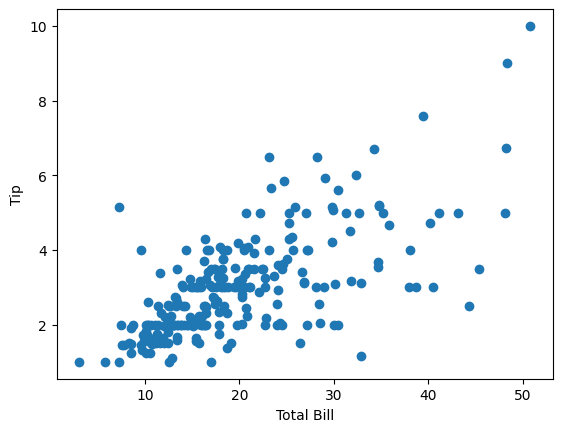

In [6]:
plt.scatter(df["total_bill"], df["tip"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

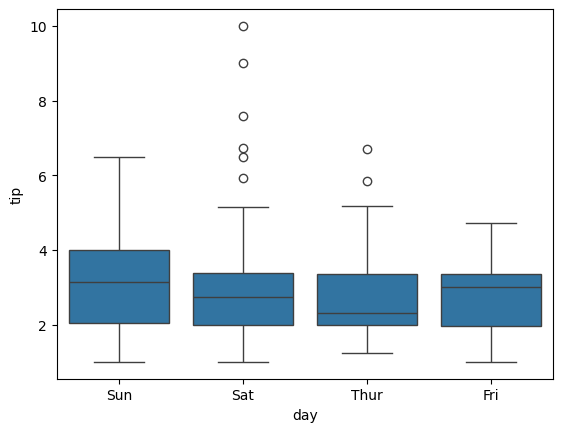

In [7]:
sns.boxplot(x="day", y="tip", data=df)
plt.show()

In [8]:
df["tip_percent"] = (df["tip"] / df["total_bill"]) * 100

In [9]:
df.groupby("sex")["tip_percent"].mean()

sex
Female    16.649074
Male      15.765055
Name: tip_percent, dtype: float64

In [10]:
df.groupby("day")["tip_percent"].mean()

day
Fri     16.991303
Sat     15.315172
Sun     16.689729
Thur    16.127563
Name: tip_percent, dtype: float64

In [11]:
df.groupby("time")["tip_percent"].mean()

time
Dinner    15.951779
Lunch     16.412793
Name: tip_percent, dtype: float64

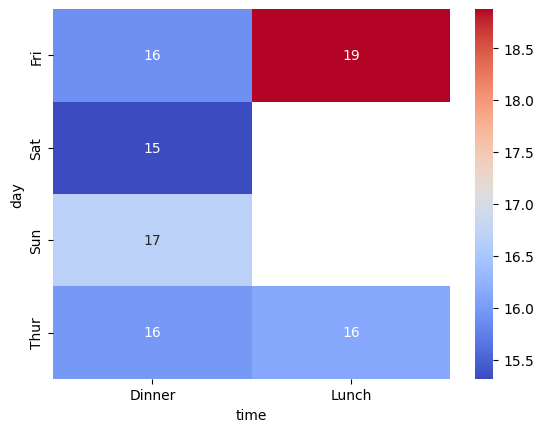

In [12]:
pivot = df.pivot_table(values="tip_percent", index="day", columns="time")
sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.show()

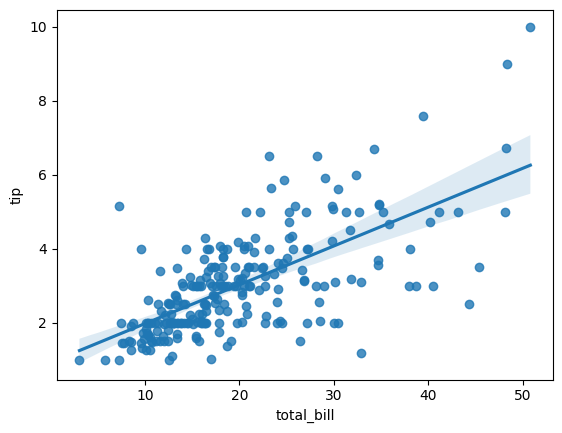

In [13]:
sns.regplot(x="total_bill", y="tip", data=df)
plt.show()

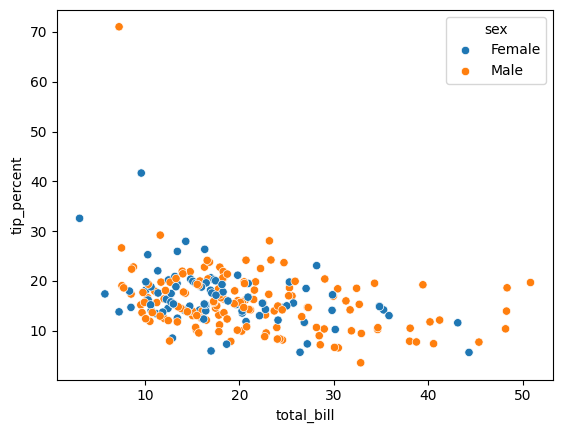

In [14]:
sns.scatterplot(x="total_bill", y="tip_percent", hue="sex", data=df)
plt.show()

In [15]:
df.corr(numeric_only=True)

,total_bill,tip,size,tip_percent
total_bill,1.000000,0.675734,0.598315,-0.338624
tip,0.675734,1.000000,0.489299,0.342370
size,0.598315,0.489299,1.000000,-0.142860
tip_percent,-0.338624,0.342370,-0.142860,1.000000


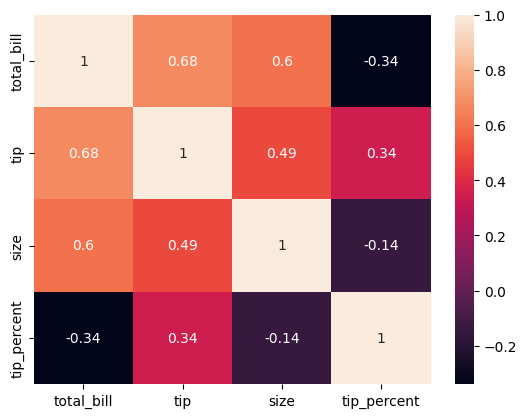

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()